# Method 1: Standard Hough Transform
Uses `cv2.HoughLines` to detect infinite lines in Canny edge-detected image.

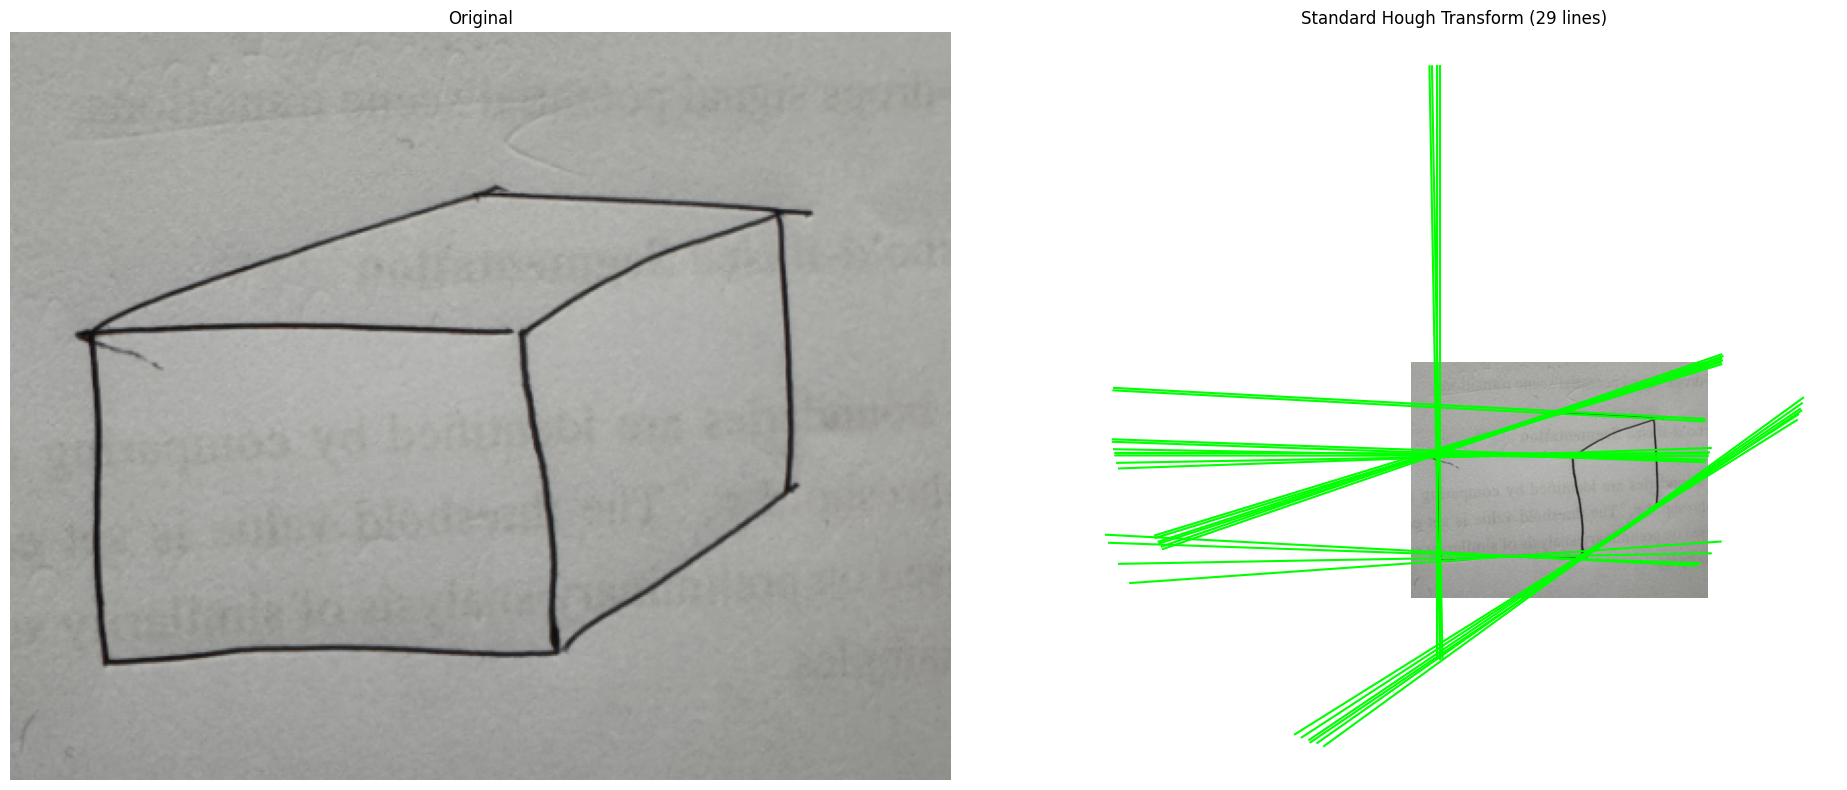

Lines detected: 29


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_color = cv2.imread('cuboid.png')
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)
edges = cv2.Canny(blurred, 50, 150)

# Standard Hough Transform returns (rho, theta) for each detected line
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=80)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_rgb)
axes[1].set_title(f'Standard Hough Transform ({len(lines) if lines is not None else 0} lines)')
axes[1].axis('off')

if lines is not None:
    h, w = img_color.shape[:2]
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        # Extend line across the entire image
        length = max(h, w)
        x1 = int(x0 + length * (-b))
        y1 = int(y0 + length * (a))
        x2 = int(x0 - length * (-b))
        y2 = int(y0 - length * (a))
        axes[1].plot([x1, x2], [y1, y2], color='lime', linewidth=1.5)

plt.tight_layout()
fig.savefig('result_hough_standard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Lines detected: {len(lines) if lines is not None else 0}')